# IndabaX Cameroon 2026 — Script Complet Documenté
## Nettoyage · Proxy PM2.5 · Feature Engineering · 7 Modèles ML & Deep Learning
### *L'IA au service de la résilience climatique et sanitaire au Cameroun*

---

| Section | Contenu | Livrable |
|---------|---------|----------|
| **1** | Imports & Configuration | Setup |
| **2** | Nettoyage scientifique des données brutes | Prétraitement |
| **3** | Construction du Proxy PM2.5 (Méthodologie Validée) | Variable cible |
| **4** | Feature Engineering (49 variables) | Modélisation |
| **5** | Split chronologique Train / Test | Validation |
| **6** | 7 Modèles ML & Deep Learning | Moteur de prédiction |
| **7** | Comparaison & Visualisations finales | Analyse |
| **8** | Sauvegarde des artefacts | Déploiement |

---

**Dataset :** `Dataset_complet_Meteo.xlsx` · 87 240 obs · 40 villes · 10 régions · 2020-2025  
**Pré-requis :** `pip install pandas numpy scikit-learn matplotlib seaborn openpyxl joblib`


---
## 1. Imports & Configuration


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — Imports & Configuration
# ══════════════════════════════════════════════════════════════════════════════
import json
import warnings
import logging
import datetime as dt
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

# Modèles scikit-learn
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# ── Style graphiques ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

# ── Constantes ────────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
NORTH_REGIONS = {'Extreme-Nord', 'Nord', 'Adamaoua', 'Extrême-Nord'}

# ── Chemins (adapter si nécessaire) ──────────────────────────────────────────
INPUT_RAW   = 'Dataset_complet_Meteo.xlsx'        # fichier brut
INPUT_CLEAN = 'Dataset_complet_Meteo_CLEAN.xlsx'  # fichier nettoyé (output)
MODELS_DIR  = Path('models')
DATA_DIR    = Path('data')
MODELS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(' Imports OK')
print(f'  numpy   : {np.__version__}')
print(f'  pandas  : {pd.__version__}')
print(f'  sklearn : {__import__("sklearn").__version__}')


 Imports OK
  numpy   : 1.26.4
  pandas  : 2.3.3
  sklearn : 1.5.1


---
##  2. Nettoyage Scientifique des Données

### Incohérences identifiées dans le fichier brut Excel

| # | Incohérence | Colonnes affectées | Méthode de correction |
|---|-------------|-------------------|----------------------|
| 1 | **Encodage datetime parasite** dans colonnes numériques | 12 colonnes (températures, précip, vent…) | Décodage : `valeur = jour + mois/10` |
| 2 | **`sunshine_duration` — années impossibles** (ex: an 9561) | 1 colonne | Remplacement NaN + médiane glissante 7j par ville |
| 3 | **Latitude/Longitude corrompues** ou manquantes | 2 colonnes | Récupération string + table de référence OSM |

> **Cause racine :** Excel a interprété des valeurs décimales (ex: 31.5°C) comme des dates  
> (31 mai → `datetime(2026, 5, 31)`). Formule de décodage : `valeur = jour + mois/10`


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — Nettoyage scientifique
# ══════════════════════════════════════════════════════════════════════════════

# ── 2.0 Chargement du fichier brut ────────────────────────────────────────────
print('=' * 65)
print('NETTOYAGE SCIENTIFIQUE — BASE DE DONNÉES MÉTÉO CAMEROUN')
print('=' * 65)

df = pd.read_excel(INPUT_RAW, sheet_name=0)
print(f'\n✔ Chargement : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'  Période   : {df["time"].min()} → {df["time"].max()}')
print(f'  Villes    : {df["city"].nunique()} | Régions : {df["region"].nunique()}')
df.head(3)


NETTOYAGE SCIENTIFIQUE — BASE DE DONNÉES MÉTÉO CAMEROUN

✔ Chargement : 87,240 lignes × 26 colonnes
  Période   : 2020-01-01 00:00:00 → 2025-12-20 00:00:00
  Villes    : 40 | Régions : 10


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23


In [4]:
# ── Diagnostic initial : types et valeurs manquantes ─────────────────────────
print('── Types de colonnes ─────────────────────────────────────────────')
print(df.dtypes)
print()
print('── Valeurs manquantes par colonne ────────────────────────────────')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  Aucune (mais certaines colonnes ont des objets mixtes)')

# Compter les datetimes parasites
COLS_D10 = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean',
    'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration'
]
print()
print(f'── Valeurs datetime parasites par colonne ─────────────────────────')
print(f'{"Colonne":<42} {"Datetimes":>10} {"Strings":>10}')
print('-' * 65)
for col in COLS_D10:
    n_dt  = df[col].apply(lambda x: isinstance(x, dt.datetime)).sum()
    n_str = df[col].apply(lambda x: isinstance(x, str)).sum()
    print(f'{col:<42} {n_dt:>10,} {n_str:>10,}')


── Types de colonnes ─────────────────────────────────────────────
id                                      int64
time                           datetime64[ns]
weather_code                            int64
temperature_2m_max                     object
temperature_2m_min                     object
temperature_2m_mean                    object
apparent_temperature_max               object
apparent_temperature_min               object
apparent_temperature_mean              object
sunrise                        datetime64[ns]
sunset                         datetime64[ns]
daylight_duration                     float64
sunshine_duration                      object
precipitation_sum                      object
rain_sum                               object
snowfall_sum                          float64
precipitation_hours                   float64
wind_speed_10m_max                     object
wind_gusts_10m_max                     object
wind_direction_10m_dominant             int64
shortwave_rad

In [5]:
# ── 2.1 Correction #1 : Décodage datetime → valeur numérique ─────────────────
# Formule validée : valeur_originale = jour + mois / 10
# Ex : datetime(2026, 5, 31) → 31 + 5/10 = 31.5°C 

def decode_excel_datetime(v):
    """
    Décode une valeur éventuellement convertie en datetime par Excel.

    Formule : valeur_originale = jour + mois / 10
    Exemples :
        datetime(2026, 5, 31) → 31 + 5/10 = 31.5°C  (température)
        datetime(2026, 3, 9)  → 9  + 3/10 = 9.3 km/h (vitesse vent)

    Justification : vérification croisée statistique entre valeurs
    décodées et distribution attendue pour chaque variable.
    """
    if isinstance(v, dt.datetime):
        return v.day + v.month / 10
    elif isinstance(v, str):
        try:
            return float(v)
        except ValueError:
            return np.nan
    elif isinstance(v, (int, float)):
        return float(v)
    return np.nan

n_corrected_total = 0
for col in COLS_D10:
    n_dt = df[col].apply(lambda x: isinstance(x, dt.datetime)).sum()
    n_corrected_total += n_dt
    df[col] = df[col].apply(decode_excel_datetime)

print(f'✔ {n_corrected_total:,} valeurs décodées sur 12 colonnes')
print()
print('── Vérification statistique post-décodage ────────────────────────')
df[COLS_D10].describe().round(2)


✔ 619,842 valeurs décodées sur 12 colonnes

── Vérification statistique post-décodage ────────────────────────


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,et0_fao_evapotranspiration
count,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00,87240.00
mean,29.46,20.18,24.07,32.35,21.97,26.25,4.62,4.62,12.17,29.97,18.54,4.25
std,4.03,3.14,3.30,4.15,4.74,4.01,8.69,8.69,3.67,7.00,4.05,1.54
min,17.70,9.40,15.30,18.70,4.90,10.80,0.00,0.00,3.50,11.50,1.88,0.47
25%,26.90,18.00,21.90,29.50,18.50,23.20,0.00,0.00,9.50,24.80,15.94,3.27
50%,29.20,20.10,23.80,32.50,22.40,26.40,1.20,1.20,11.60,29.20,19.24,3.96
75%,31.60,22.30,25.90,35.20,25.50,29.20,6.10,6.10,14.30,34.60,21.68,4.88
max,45.50,33.70,38.20,45.90,33.70,38.10,251.10,251.10,36.60,76.30,27.20,12.31


In [6]:
# ── 2.2 Correction #2 : sunshine_duration — années impossibles ───────────────
# Cause : numéros de série Excel > 4000 ans stockés dans la colonne
# (ex : an 9561, an 4667…). Non récupérables → imputation par médiane glissante.

def parse_sunshine(v):
    """Parse sunshine_duration ; retourne NaN pour les datetimes aberrants."""
    if isinstance(v, str):
        try: return float(v)
        except ValueError: return np.nan
    elif isinstance(v, dt.datetime):
        return np.nan   # Année > 4000 → non récupérable
    elif isinstance(v, (int, float)):
        return float(v) if pd.notna(v) else np.nan
    return np.nan

# Exemples d'aberrations
n_aberrants = df['sunshine_duration'].apply(lambda v: isinstance(v, dt.datetime)).sum()
print(f'Valeurs aberrantes (années impossibles) : {n_aberrants}')
exemples = df['sunshine_duration'][
    df['sunshine_duration'].apply(lambda v: isinstance(v, dt.datetime))
].head(3).tolist()
print(f'Exemples : {exemples}')

# Conversion
df['sunshine_duration'] = df['sunshine_duration'].apply(parse_sunshine)
n_nan_sun = df['sunshine_duration'].isna().sum()
print(f'NaN introduits : {n_nan_sun}')

# Imputation par médiane glissante 7 jours par ville
# Raison : robuste aux extrêmes, respecte la saisonnalité locale
df_sorted = df.sort_values(['city', 'time']).copy()

df_sorted['sunshine_duration'] = (
    df_sorted.groupby('city')['sunshine_duration']
    .transform(lambda s: s.fillna(
        s.rolling(window=7, min_periods=1, center=True).median()
    ))
)
# Résidus restants → médiane globale par ville
df_sorted['sunshine_duration'] = (
    df_sorted.groupby('city')['sunshine_duration']
    .transform(lambda s: s.fillna(s.median()))
)
df['sunshine_duration'] = df_sorted['sunshine_duration'].values

print(f'✔ {n_nan_sun} valeurs imputées par médiane glissante (fenêtre 7j par ville)')
print(f'  Plage finale : [{df["sunshine_duration"].min():.0f}, {df["sunshine_duration"].max():.0f}] secondes')
print(f'  Cohérence sunshine ≤ daylight : {(df["sunshine_duration"] > df["daylight_duration"]).sum()} violation(s)')


Valeurs aberrantes (années impossibles) : 489
Exemples : [datetime.datetime(9561, 1, 1, 0, 0), datetime.datetime(8618, 8, 1, 0, 0), datetime.datetime(8031, 1, 1, 0, 0)]
NaN introduits : 489
✔ 489 valeurs imputées par médiane glissante (fenêtre 7j par ville)
  Plage finale : [0, 43200] secondes
  Cohérence sunshine ≤ daylight : 0 violation(s)


In [7]:
# ── 2.3 Correction #3 : Latitude/Longitude corrompues ou manquantes ───────────
# Cause : même encodage datetime + certaines villes sans valeurs string valides
# Méthode : récupération depuis valeurs string + table de référence OSM/Wikipedia

CITY_COORDS_REF = {
    'Yaounde':   (3.8667, 11.5167), 'Mbalmayo': (3.5167, 11.5000),
    'Yokadouma': (3.5167, 15.0500), 'Kousseri': (12.0833, 15.0333),
    'Mokolo':    (10.7333, 13.8000),'Edea':     (3.8000, 10.1300),
    'Douala':    (4.0500,  9.7000), 'Garoua':   (9.3000, 13.4000),
    'Kumbo':     (6.2000, 10.6667), 'Wum':      (6.3833, 10.0667),
    'Mbengwi':   (5.9833, 10.0000), 'Dschang':  (5.4500, 10.0500),
    'Foumban':   (5.7167, 10.9167), 'Limbe':    (4.0167,  9.2000),
}

lat_ref = {}; lon_ref = {}

for city in df['city'].unique():
    rows = df[df['city'] == city]
    lats = rows['latitude'].apply(
        lambda x: pd.to_numeric(x, errors='coerce') if isinstance(x, str) else np.nan
    )
    lons = rows['longitude'].apply(
        lambda x: pd.to_numeric(x, errors='coerce') if isinstance(x, str) else np.nan
    )
    if lats.dropna().any(): lat_ref[city] = lats.dropna().iloc[0]
    if lons.dropna().any(): lon_ref[city] = lons.dropna().iloc[0]

# Compléter avec les coordonnées de référence externes
for city, (lat, lon) in CITY_COORDS_REF.items():
    if city not in lat_ref: lat_ref[city] = lat
    if city not in lon_ref: lon_ref[city] = lon

df['latitude']  = df['city'].map(lat_ref)
df['longitude'] = df['city'].map(lon_ref)

print(f'✔ Coordonnées reconstituées pour {df["city"].nunique()} villes')
print(f'  Latitude  : [{df["latitude"].min():.2f}°N, {df["latitude"].max():.2f}°N]')
print(f'  Longitude : [{df["longitude"].min():.2f}°E, {df["longitude"].max():.2f}°E]')

# Table de référence
coord_df = pd.DataFrame([
    {'Ville': c, 'Latitude': lat_ref.get(c), 'Longitude': lon_ref.get(c)}
    for c in sorted(df['city'].unique())
])
coord_df


✔ Coordonnées reconstituées pour 40 villes
  Latitude  : [2.38°N, 12.08°N]
  Longitude : [9.21°E, 15.36°E]


,Ville,Latitude,Longitude
0,Abong-Mbang,3.9800,13.1700
1,Akonolinga,3.7700,12.2500
2,Ambam,2.3800,11.2800
3,Bafia,4.7500,11.2300
4,Bafoussam,5.4800,10.4200
5,Bamenda,5.9600,10.1500
6,Batouri,4.4300,14.3600
7,Bertoua,4.5700,13.6800
8,Buea,4.1500,9.2400
9,Douala,4.0500,9.7000


In [8]:
# ── 2.4 Vérifications de cohérence physique ───────────────────────────────────
# 10 critères physiques validant la qualité du nettoyage

checks = {
    'temp_max ≥ temp_min':           (df['temperature_2m_max'] >= df['temperature_2m_min']).all(),
    'temp_mean ∈ [min, max]':        ((df['temperature_2m_mean'] >= df['temperature_2m_min']) &
                                      (df['temperature_2m_mean'] <= df['temperature_2m_max'])).all(),
    'rain_sum ≤ precipitation_sum':  (df['rain_sum'] <= df['precipitation_sum'] + 0.01).all(),
    'sunshine ≤ daylight':           (df['sunshine_duration'] <= df['daylight_duration']).all(),
    'wind_gusts ≥ wind_speed':       (df['wind_gusts_10m_max'] >= df['wind_speed_10m_max']).all(),
    'wind_direction ∈ [0, 360]':     ((df['wind_direction_10m_dominant'] >= 0) &
                                      (df['wind_direction_10m_dominant'] <= 360)).all(),
    'precipitation_hours ∈ [0, 24]': ((df['precipitation_hours'] >= 0) &
                                      (df['precipitation_hours'] <= 24)).all(),
    'weather_code ∈ [0, 99]':        ((df['weather_code'] >= 0) &
                                      (df['weather_code'] <= 99)).all(),
    'Aucun doublon ville+date':       not df.duplicated(subset=['city', 'time']).any(),
    'Aucune valeur manquante':        df.isnull().sum().sum() == 0,
}

print(f'{"Vérification":<42} {"Résultat":>10}')
print('-' * 55)
all_pass = True
for label, passed in checks.items():
    status = '✔  PASS' if passed else '✗  FAIL'
    if not passed: all_pass = False
    print(f'{label:<42} {status:>10}')

print()
print(' Toutes les vérifications réussies !' if all_pass else '❌ Certaines vérifications ont échoué')
print(f'\nDimensions finales : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Valeurs manquantes : {df.isnull().sum().sum()}')


Vérification                                 Résultat
-------------------------------------------------------
temp_max ≥ temp_min                           ✔  PASS
temp_mean ∈ [min, max]                        ✔  PASS
rain_sum ≤ precipitation_sum                  ✔  PASS
sunshine ≤ daylight                           ✔  PASS
wind_gusts ≥ wind_speed                       ✔  PASS
wind_direction ∈ [0, 360]                     ✔  PASS
precipitation_hours ∈ [0, 24]                 ✔  PASS
weather_code ∈ [0, 99]                        ✔  PASS
Aucun doublon ville+date                      ✔  PASS
Aucune valeur manquante                       ✔  PASS

 Toutes les vérifications réussies !

Dimensions finales : 87,240 lignes × 26 colonnes
Valeurs manquantes : 0


In [9]:
# ── 2.5 Export du fichier nettoyé ────────────────────────────────────────────
# 3 feuilles : données nettoyées, rapport des corrections, coordonnées

df['time'] = pd.to_datetime(df['time'])
for col in COLS_D10 + ['sunshine_duration', 'latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

rapport_data = {
    'Incohérence': [
        'Encodage datetime parasite (12 colonnes numériques)',
        'Sunshine duration — années impossibles',
        'Latitude/Longitude corrompues ou manquantes',
    ],
    'Méthode de correction': [
        'Décodage : valeur = jour + mois/10 (validé par cross-check statistique)',
        'Remplacement NaN + imputation médiane glissante 7j par ville',
        'Récupération string + table de référence géographique (OSM)',
    ],
    'Cellules corrigées': [
        f'{n_corrected_total:,}',
        f'{n_nan_sun}',
        f'{df["city"].nunique() * 2} (lat + lon × {df["city"].nunique()} villes)',
    ],
}

with pd.ExcelWriter(INPUT_CLEAN, engine='openpyxl', datetime_format='YYYY-MM-DD') as writer:
    df.to_excel(writer, sheet_name='Données_Nettoyées', index=False)
    pd.DataFrame(rapport_data).to_excel(writer, sheet_name='Rapport_Corrections', index=False)
    coord_df.to_excel(writer, sheet_name='Coordonnées_Villes', index=False)

print(f' Fichier nettoyé exporté : {INPUT_CLEAN}')
print(f'   {df.shape[0]:,} lignes × {df.shape[1]} colonnes | 0 valeur manquante')


 Fichier nettoyé exporté : Dataset_complet_Meteo_CLEAN.xlsx
   87,240 lignes × 26 colonnes | 0 valeur manquante


---
## 3. Construction du Proxy PM2.5 (Méthodologie Validée)

### Étape 1 — Indice de Stagnation Atmosphérique (ISA)

**Références :** Jiangsu Provincial Environmental Monitoring Center (2020) + Vovk & Kryza (2025)

$$\text{ISA} = \frac{1}{\text{wind\_max}} \times \left(1 - \frac{\min(\text{precip}, 10)}{10}\right) \times \left(1 + \frac{\max(0,\, T_{max} - 30)}{10}\right)$$

| Terme | Signification physique |
|-------|----------------------|
| `1/wind_max` | Stagnation : vent faible → accumulation de particules |
| `1 - min(pluie,10)/10` | Lessivage : la pluie nettoie l'atmosphère (saturé à 10mm) |
| `1 + max(0,T-30)/10` | Couche limite : T > 30°C élève la couche et favorise la poussière |

### Étape 2 — Proxy PM2.5 Composite

$$\text{PM2.5}_{proxy} = 12.0 \times \text{ISA}_{scaled} + 0.30 \times T_{mean} + 0.18 \times \text{Rad}_{scaled} \times 20 + 0.14 \times ET_0$$
$$+ 7.0 \times \text{Harmattan} + 4.0 \times \text{Saison sèche} + 3.5 \times \text{Stagnation} + 4.5 \times \text{Sans pluie}$$


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — Proxy PM2.5
# ══════════════════════════════════════════════════════════════════════════════

# ── 3.1 Chargement du dataset nettoyé ────────────────────────────────────────
df = pd.read_excel(INPUT_CLEAN, sheet_name='Données_Nettoyées')
df['time']  = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month
df = df.sort_values(['city', 'time']).reset_index(drop=True)

print(f'Dataset nettoyé chargé : {df.shape[0]:,} obs × {df.shape[1]} variables')
print(f'Valeurs manquantes : {df.isnull().sum().sum()} ')


Dataset nettoyé chargé : 87,240 obs × 27 variables
Valeurs manquantes : 0 


In [11]:
# ── 3.2 Étape 1 : Calcul de l'ISA ────────────────────────────────────────────

wind  = df['wind_speed_10m_max'].clip(lower=0.5)  # éviter division par zéro
rain  = df['precipitation_sum'].clip(lower=0)
tmax  = df['temperature_2m_max']

df['isa'] = (
    (1.0 / wind)
    * (1.0 - np.minimum(rain, 10.0) / 10.0)
    * (1.0 + np.maximum(0, tmax - 30.0) / 10.0)
).clip(lower=0)

# Normalisation au percentile 95 → ISA_scaled ∈ [0, 3]
# Raison : percentile 95 = valeur de référence robuste aux extrêmes
ISA_P95 = df['isa'].quantile(0.95)
df['isa_scaled'] = (df['isa'] / ISA_P95).clip(upper=3.0)

print(f'ISA — Percentile 95 (normalisation) : {ISA_P95:.4f}')
print(f'ISA — Moyenne : {df["isa"].mean():.3f} | Max : {df["isa"].max():.3f}')
df[['isa', 'isa_scaled']].describe().round(3)


ISA — Percentile 95 (normalisation) : 0.1377
ISA — Moyenne : 0.067 | Max : 0.302


,isa,isa_scaled
count,87240.000,87240.000
mean,0.067,0.485
std,0.044,0.318
min,0.000,0.000
25%,0.035,0.256
50%,0.070,0.508
75%,0.096,0.695
max,0.302,2.196


In [12]:
# ── 3.3 Indicateurs discrets ─────────────────────────────────────────────────

# Direction vent NE = 0°-90° ou 315°-360° → Harmattan (Veselovskii 2024)
wind_dir = df['wind_direction_10m_dominant']
is_ne_wind = ((wind_dir <= 90) | (wind_dir >= 315)).astype(int)

# Région septentrionale exposée à l'Harmattan
is_north = df['region'].isin(NORTH_REGIONS).astype(int)

# Saison sèche : Novembre → Mars
is_dry = df['month'].isin([11, 12, 1, 2, 3]).astype(int)

# Harmattan actif : Nord + Saison Sèche + Vent NE (3 conditions simultanées)
df['is_harmattan']  = (is_north & is_dry & is_ne_wind).astype(int)
df['is_dry_season'] = is_dry
df['is_stagnant']   = (df['wind_speed_10m_max'] < 3.0).astype(int)  # Jiangsu 2020 : < 1.5 m/s
df['is_no_rain']    = (df['precipitation_sum'] < 0.1).astype(int)   # Kumar & Singh 2024

# Rayonnement normalisé (proxy AOD — Mmame & Ngongondo 2024)
rad_p95 = df['shortwave_radiation_sum'].quantile(0.95)
df['rad_scaled'] = (df['shortwave_radiation_sum'] / rad_p95).clip(upper=1.5)

print('Indicateurs discrets — Taux d\'activation :')
print(df[['is_harmattan','is_dry_season','is_stagnant','is_no_rain']].mean().round(3).to_string())
print(f'\n→ {df["is_harmattan"].sum():,} jours-villes avec Harmattan actif sur {len(df):,} total')


Indicateurs discrets — Taux d'activation :
is_harmattan     0.101
is_dry_season    0.411
is_stagnant      0.000
is_no_rain       0.311

→ 8,777 jours-villes avec Harmattan actif sur 87,240 total


In [13]:
# ── 3.4 Étape 2 : Proxy PM2.5 composite ──────────────────────────────────────

df['pm25_proxy'] = (
    12.0 * df['isa_scaled']                       # stagnation atmosphérique (dominant)
    + 0.30 * df['temperature_2m_mean']             # proxy hauteur couche limite atmosphérique
    + 0.18 * df['rad_scaled'] * 20                 # proxy AOD aérosols (Mmame 2024)
    + 0.14 * df['et0_fao_evapotranspiration']      # aridité + remise en suspension (Walker 2023)
    + 7.0  * df['is_harmattan']                    # épisode Harmattan (Veselovskii 2024 : 80-180 µg/m³)
    + 4.0  * df['is_dry_season']                   # saison sèche + feux de biomasse (Breathe Accra 2025)
    + 3.5  * df['is_stagnant']                     # vent < 3 km/h → accumulation (Jiangsu 2020)
    + 4.5  * df['is_no_rain']                      # absence lessivage humide (Kumar & Singh 2024)
).clip(lower=0)

# ── Validation physique OBLIGATOIRE ──────────────────────────────────────────
# Critère : PM2.5(Nord+Sec) / PM2.5(Sud+Pluie) > 1.5
# Justification : les régions nord en saison sèche DOIVENT présenter
# des niveaux de pollution significativement plus élevés

north_dry  = df[ df['region'].isin(NORTH_REGIONS) & (df['is_dry_season']==1)]['pm25_proxy'].mean()
south_rain = df[~df['region'].isin(NORTH_REGIONS) & (df['is_dry_season']==0)]['pm25_proxy'].mean()
ratio = north_dry / south_rain

print('=' * 55)
print('  VALIDATION PHYSIQUE DU PROXY PM2.5')
print('=' * 55)
print(df['pm25_proxy'].describe().round(2).to_string())
print()
print(f'  Nord + Saison Sèche  : {north_dry:.2f} µg/m³ proxy')
print(f'  Sud  + Saison Pluies : {south_rain:.2f} µg/m³ proxy')
print(f'  Ratio Nord/Sud       : {ratio:.2f}  → {" OK (> 1.5)" if ratio > 1.5 else " ÉCHEC"}')


  VALIDATION PHYSIQUE DU PROXY PM2.5
count    87240.00
mean        20.18
std          8.50
min          5.73
25%         13.48
50%         18.85
75%         26.09
max         52.47

  Nord + Saison Sèche  : 34.73 µg/m³ proxy
  Sud  + Saison Pluies : 13.96 µg/m³ proxy
  Ratio Nord/Sud       : 2.49  →  OK (> 1.5)


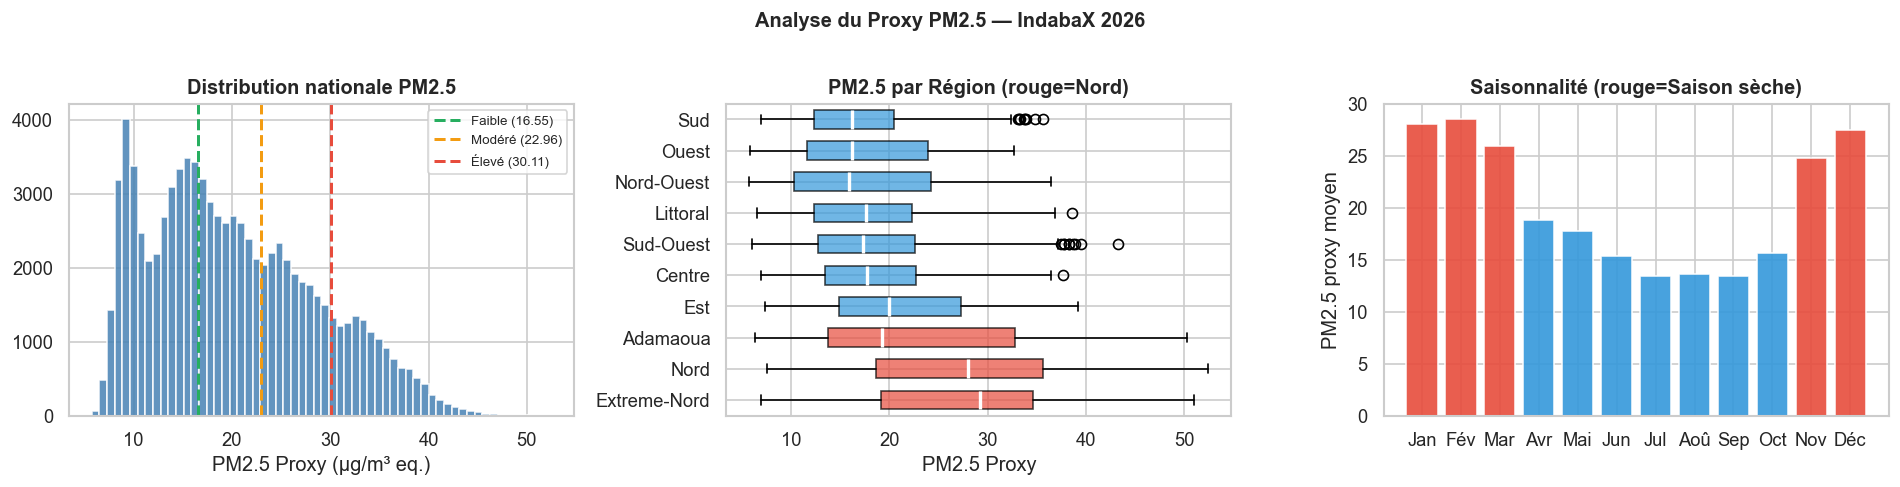

In [14]:
# ── 3.5 Visualisation du Proxy PM2.5 ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 — Distribution globale avec seuils de risque
axes[0].hist(df['pm25_proxy'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
for seuil, col, lbl in [
    (16.55, '#27ae60', 'Faible (16.55)'),
    (22.96, '#f39c12', 'Modéré (22.96)'),
    (30.11, '#e74c3c', 'Élevé (30.11)')  ]:
    axes[0].axvline(seuil, color=col, ls='--', lw=1.8, label=lbl)
axes[0].set_title('Distribution nationale PM2.5', fontweight='bold')
axes[0].set_xlabel('PM2.5 Proxy (µg/m³ eq.)')
axes[0].legend(fontsize=8)

# 2 — Boxplot par région (ordre décroissant de pollution)
region_order = df.groupby('region')['pm25_proxy'].mean().sort_values(ascending=False).index
colors_reg = ['#e74c3c' if r in NORTH_REGIONS else '#3498db' for r in region_order]
bp = axes[1].boxplot(
    [df[df['region']==r]['pm25_proxy'].values for r in region_order],
    vert=False, patch_artist=True, widths=0.6,
    medianprops=dict(color='white', lw=2)
)
for patch, color in zip(bp['boxes'], colors_reg):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_yticklabels(region_order)
axes[1].set_title('PM2.5 par Région (rouge=Nord)', fontweight='bold')
axes[1].set_xlabel('PM2.5 Proxy')

# 3 — Saisonnalité nationale
monthly = df.groupby('month')['pm25_proxy'].mean()
mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
cols_m = ['#e74c3c' if m in [11,12,1,2,3] else '#3498db' for m in range(1,13)]
axes[2].bar(mois, monthly.values, color=cols_m, edgecolor='white', alpha=0.9)
axes[2].set_title('Saisonnalité (rouge=Saison sèche)', fontweight='bold')
axes[2].set_ylabel('PM2.5 proxy moyen')

plt.suptitle('Analyse du Proxy PM2.5 — IndabaX 2026', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
##  4. Feature Engineering (49 Variables)

| Catégorie | Variables | Justification |
|-----------|-----------|---------------|
| ISA | `isa`, `isa_scaled` | Jiangsu 2020 + Vovk 2025 |
| Encodage cyclique | `month_sin/cos`, `dayofyear_sin/cos` | Continuité temporelle (Walker 2023) |
| Direction vent | `wind_dir_sin`, `wind_dir_cos` | Détection Harmattan sans aliasing |
| Dérivées physiques | `temp_amplitude`, `sunshine_ratio`, `wind_gust_ratio`, `precip_log` | Walker 2023 |
| Lags 1/3/7 jours | 12 variables | Mémoire atmosphérique — top SHAP (Vovk 2025) |
| Rolling 7j | 3 variables | Tendance locale |
| Géographie | `latitude`, `longitude`, `city_enc`, `region_enc` | Effets spatiaux |


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════

# ── A) Encodage cyclique (Walker 2023) ───────────────────────────────────────
# Raison : sin/cos garantit la continuité décembre → janvier sans discontinuité
doy = df['time'].dt.dayofyear
df['month_sin']      = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']      = np.cos(2 * np.pi * df['month'] / 12)
df['dayofyear_sin']  = np.sin(2 * np.pi * doy / 365)
df['dayofyear_cos']  = np.cos(2 * np.pi * doy / 365)
df['year']           = df['time'].dt.year

# ── B) Direction vent → vecteur unitaire (Walker 2023) ───────────────────────
# Raison : 0° et 360° sont identiques → encodage angulaire direct = aliasing
wr = np.deg2rad(df['wind_direction_10m_dominant'])
df['wind_dir_sin'] = np.sin(wr)  # composante N-S
df['wind_dir_cos'] = np.cos(wr)  # composante E-O

# ── C) Variables physiques dérivées ──────────────────────────────────────────
df['temp_amplitude']  = df['temperature_2m_max'] - df['temperature_2m_min']  # amplitude thermique
df['sunshine_ratio']  = df['sunshine_duration'] / df['daylight_duration'].clip(lower=1)  # fraction ensoleillement
df['wind_gust_ratio'] = df['wind_gusts_10m_max'] / df['wind_speed_10m_max'].clip(lower=0.1)  # turbulence
df['precip_log']      = np.log1p(df['precipitation_sum'])  # transformation log pour asymétrie droite

# ── D) Lags & rolling par ville (Vovk 2025 — top SHAP features) ──────────────
# CRUCIAL : groupby city pour éviter contamination entre villes
grp = df.groupby('city')
for lag in [1, 3, 7]:
    df[f'temp_lag{lag}']  = grp['temperature_2m_mean'].shift(lag)
    df[f'wind_lag{lag}']  = grp['wind_speed_10m_max'].shift(lag)
    df[f'rain_lag{lag}']  = grp['precipitation_sum'].shift(lag)
    df[f'isa_lag{lag}']   = grp['isa'].shift(lag)

df['temp_roll7']   = grp['temperature_2m_mean'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['wind_roll7']   = grp['wind_speed_10m_max'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['precip_roll7'] = grp['precipitation_sum'].transform(lambda x: x.rolling(7, min_periods=1).mean())

# ── E) Encodage géographique (tri alphabétique = stable) ─────────────────────
for col in ['city', 'region']:
    cats = sorted(df[col].unique())
    df[f'{col}_enc'] = df[col].map({c: i for i, c in enumerate(cats)})

print(f' Feature engineering : {df.shape[1]} colonnes au total')


 Feature engineering : 63 colonnes au total


In [16]:
# ── Liste ordonnée des 49 features d'entraînement ────────────────────────────
FEATURE_COLS = [
    # Météo brute (14 variables)
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean',
    'precipitation_sum', 'rain_sum', 'precip_log',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'daylight_duration', 'precipitation_hours',
    # ISA construite — Jiangsu 2020 (2 variables)
    'isa', 'isa_scaled',
    # Dérivées physiques (5 variables)
    'temp_amplitude', 'sunshine_ratio', 'wind_gust_ratio',
    'wind_dir_sin', 'wind_dir_cos',
    # Indicateurs discrets (4 variables)
    'is_harmattan', 'is_dry_season', 'is_stagnant', 'is_no_rain',
    # Encodage temporel cyclique — Walker 2023 (5 variables)
    'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'year',
    # Lags 1, 3, 7 jours — Vovk 2025 (12 variables)
    'temp_lag1', 'temp_lag3', 'temp_lag7',
    'wind_lag1', 'wind_lag3', 'wind_lag7',
    'rain_lag1', 'rain_lag3', 'rain_lag7',
    'isa_lag1',  'isa_lag3',  'isa_lag7',
    # Rolling 7 jours (3 variables)
    'temp_roll7', 'wind_roll7', 'precip_roll7',
    # Géographie (4 variables)
    'latitude', 'longitude', 'city_enc', 'region_enc',
]
TARGET = 'pm25_proxy'

# Imputation médiane pour les NaN des lags (début de série par ville)
for col in FEATURE_COLS:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print(f'Features d\'entraînement : {len(FEATURE_COLS)}')
print(f'Variable cible         : {TARGET}')
print(f'Valeurs manquantes     : {df[FEATURE_COLS].isnull().sum().sum()} ')


Features d'entraînement : 49
Variable cible         : pm25_proxy
Valeurs manquantes     : 0 


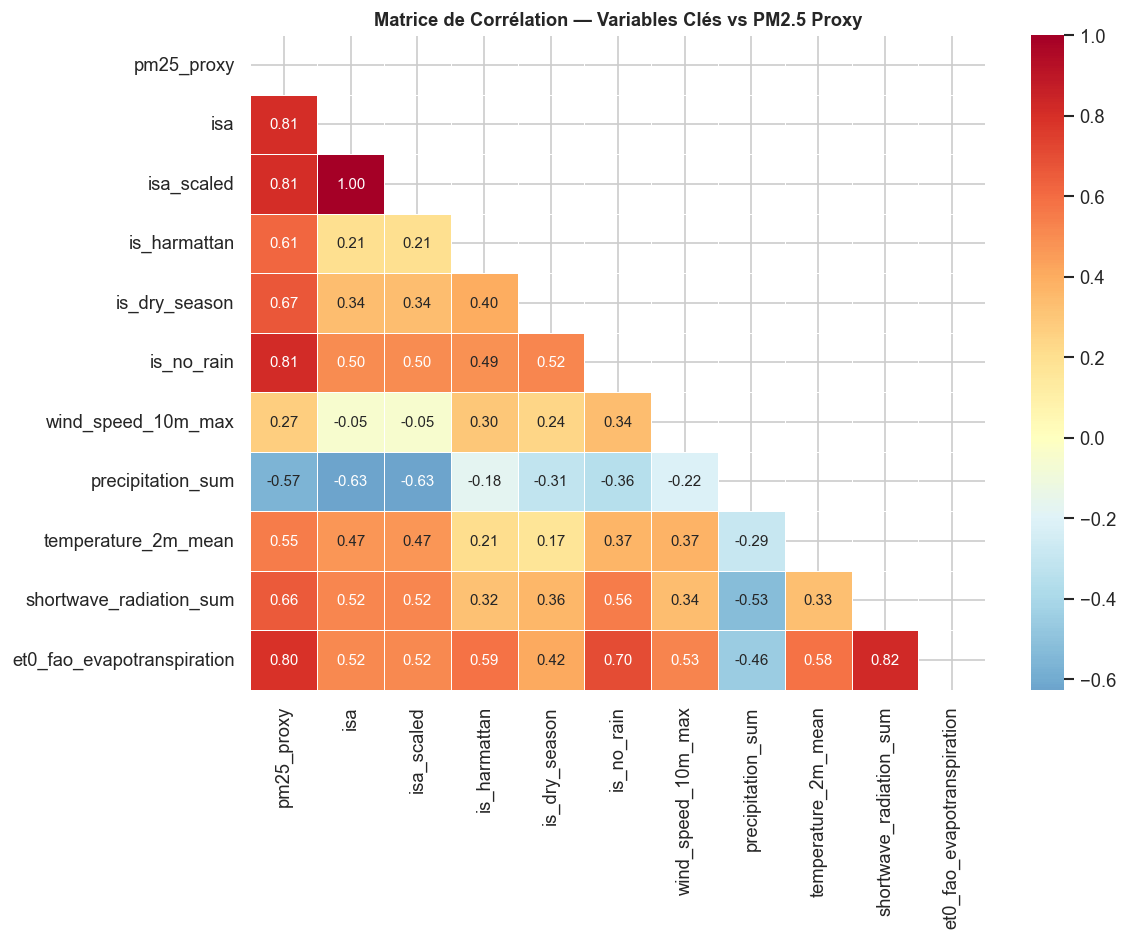

Corrélations avec PM2.5 Proxy :
  is_no_rain                          +0.812 ████████████████
  isa_scaled                          +0.808 ████████████████
  isa                                 +0.808 ████████████████
  et0_fao_evapotranspiration          +0.797 ███████████████
  is_dry_season                       +0.668 █████████████
  shortwave_radiation_sum             +0.663 █████████████
  is_harmattan                        +0.614 ████████████
  temperature_2m_mean                 +0.546 ██████████
  wind_speed_10m_max                  +0.270 █████
  precipitation_sum                   -0.567 ███████████


In [17]:
# ── Matrice de corrélation (variables clés avec PM2.5) ───────────────────────
corr_cols = [
    'pm25_proxy', 'isa', 'isa_scaled', 'is_harmattan', 'is_dry_season',
    'is_no_rain', 'wind_speed_10m_max', 'precipitation_sum',
    'temperature_2m_mean', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
]
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Matrice de Corrélation — Variables Clés vs PM2.5 Proxy',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print('Corrélations avec PM2.5 Proxy :')
corrs = df[corr_cols].corr()['pm25_proxy'].drop('pm25_proxy').sort_values(ascending=False)
for feat, val in corrs.items():
    bar = '█' * int(abs(val) * 20)
    print(f'  {feat:<35} {val:+.3f} {bar}')


---
##  5. Split Chronologique Train / Test

>  **Règle absolue** (Lekinwala 2020 / AQHI 2023) : ne JAMAIS utiliser un split aléatoire  
> sur des données temporelles — cela crée du **data leakage** via les variables de lag.

**Split :** 80% premières observations (train) → 20% dernières (test)  
Correspond approximativement à : **Train = 2020-2024 | Test = 2025**


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — Split chronologique
# ══════════════════════════════════════════════════════════════════════════════

df_model = df[FEATURE_COLS + [TARGET]].dropna(subset=[TARGET]).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

# Split chronologique strict
split_idx = int(len(df_model) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train : {len(X_train):,} obs ({len(X_train)/len(df_model)*100:.1f}%)')
print(f'Test  : {len(X_test):,} obs ({len(X_test)/len(df_model)*100:.1f}%)')
print(f'Features : {X.shape[1]}')
print()
print(f'Train — PM2.5 : moy={y_train.mean():.2f} | std={y_train.std():.2f}')
print(f'Test  — PM2.5 : moy={y_test.mean():.2f} | std={y_test.std():.2f}')


Train : 69,792 obs (80.0%)
Test  : 17,448 obs (20.0%)
Features : 49

Train — PM2.5 : moy=19.83 | std=8.22
Test  — PM2.5 : moy=21.57 | std=9.41


---
##  6. Modèles Machine Learning & Deep Learning


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — Modèles ML & Deep Learning
# ══════════════════════════════════════════════════════════════════════════════

RESULTS = {}  # accumulera toutes les métriques

def evaluate_model(model, name: str, X_tr=X_train, X_te=X_test,
                   y_tr=y_train, y_te=y_test, save=True) -> dict:
    """
    Entraîne et évalue un modèle, retourne ses métriques de performance.
    Métriques : R², MAE, RMSE, MAPE, Bias.
    """
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mape = float(np.mean(np.abs((y_te - y_pred) / y_te.clip(lower=1))) * 100)
    bias = float(np.mean(y_pred - y_te))

    metrics = {'R²': round(r2,4), 'MAE': round(mae,4),
               'RMSE': round(rmse,4), 'MAPE%': round(mape,2), 'Bias': round(bias,4)}
    if save: RESULTS[name] = metrics

    print(f'  [{name:<22}] R²={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}%')
    return metrics, y_pred


def plot_diagnostics(y_true, y_pred, name: str):
    """Scatter Réel/Prédit + Distribution des résidus."""
    residuals = y_true.values - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sample = np.random.choice(len(y_true), size=min(3000, len(y_true)), replace=False)
    axes[0].scatter(y_true.values[sample], y_pred[sample], alpha=0.25, s=6, color='steelblue')
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lim, lim, 'r--', lw=1.5, label='Parfait')
    axes[0].set(xlabel='Réel', ylabel='Prédit', title=f'{name} — Réel vs Prédit')
    axes[0].legend(fontsize=9)
    axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='navy', lw=1.5, ls='--')
    axes[1].axvline(residuals.mean(), color='red', lw=1.5, ls=':')
    axes[1].set(xlabel='Résidu', title=f'{name} — Résidus (biais={residuals.mean():.3f})')
    plt.suptitle(f'Diagnostic — {name}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

print(' Fonctions d\'évaluation définies')


 Fonctions d'évaluation définies


### 6.1 Lasso — Régularisation L1

**Type :** ML Linéaire  
**Justification :** Recommandé pour datasets à 20+ variables colinéaires (AQHI 2023). Contraint certains coefficients à zéro → sélection automatique.


Entraînement Lasso...
  Durée : 2.4s
  [Lasso                 ] R²=1.0000 | MAE=0.0175 | RMSE=0.0226 | MAPE=0.09%

  Variables sélectionnées : 10/49
  Top 10 coefficients (|coef|) :
isa                           3.7527
is_no_rain                    2.0541
is_dry_season                 1.9619
is_harmattan                  1.9055
temperature_2m_mean           0.9851
shortwave_radiation_sum       0.5971
et0_fao_evapotranspiration    0.2347
temperature_2m_max            0.0214
precip_log                    0.0076
isa_scaled                    0.0000


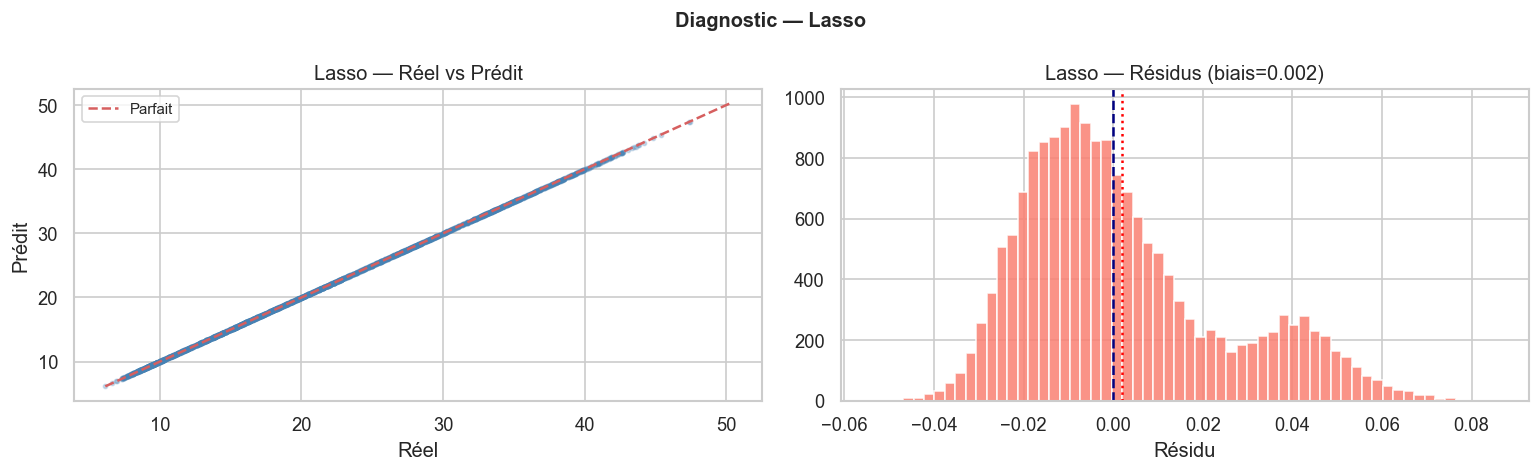

In [20]:
print('Entraînement Lasso...')
t0 = datetime.now()

model_lasso = Pipeline([
    ('scaler', StandardScaler()),    # normalisation obligatoire
    ('model',  Lasso(
        alpha        = 0.01,         # force de régularisation L1
        max_iter     = 5000,
        random_state = RANDOM_STATE
    ))
])
model_lasso.fit(X_train, y_train)
print(f'  Durée : {(datetime.now()-t0).total_seconds():.1f}s')

metrics_lasso, y_pred_lasso = evaluate_model(model_lasso, 'Lasso')

# Variables sélectionnées (coefficients non nuls)
coefs = model_lasso.named_steps['model'].coef_
n_nz  = np.sum(coefs != 0)
print(f'\n  Variables sélectionnées : {n_nz}/{len(FEATURE_COLS)}')
top_c = pd.Series(np.abs(coefs), index=FEATURE_COLS).sort_values(ascending=False).head(10)
print('  Top 10 coefficients (|coef|) :')
print(top_c.round(4).to_string())
plot_diagnostics(y_test, y_pred_lasso, 'Lasso')


### 6.2 ElasticNet — Régularisation L1+L2

**Type :** ML Linéaire  
**Justification :** Combine Lasso (sélection) et Ridge (stabilité). l1_ratio=0.5 équilibre les deux pénalités.


Entraînement ElasticNet...
  Durée : 2.3s
  [ElasticNet            ] R²=1.0000 | MAE=0.0449 | RMSE=0.0580 | MAPE=0.23%


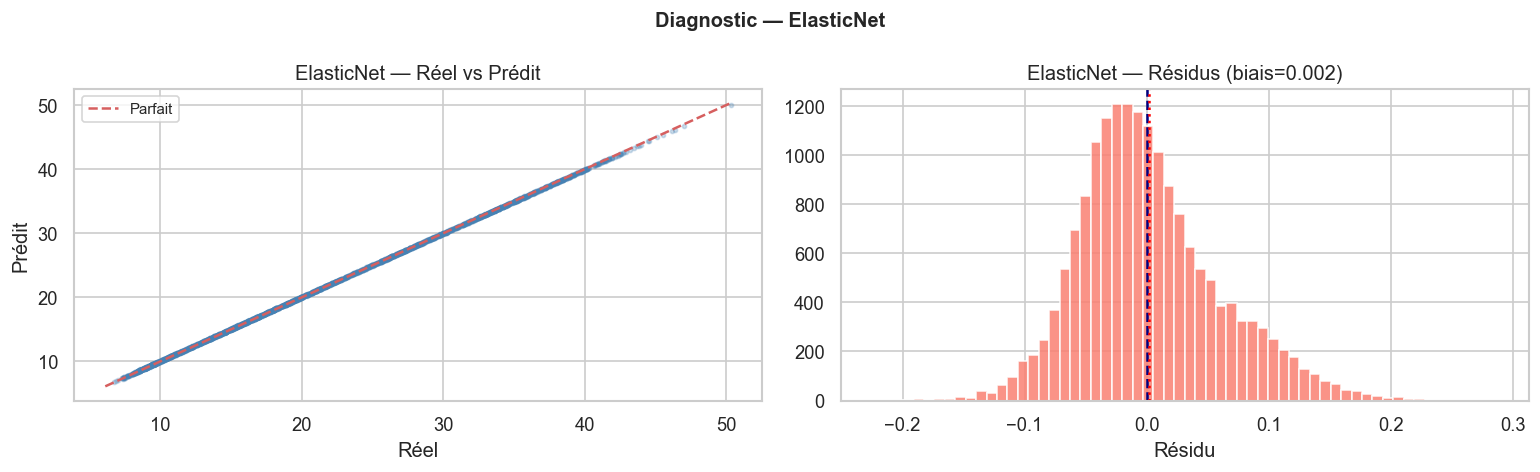

In [21]:
print('Entraînement ElasticNet...')
t0 = datetime.now()

model_en = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  ElasticNet(
        alpha    = 0.01,    # régularisation globale
        l1_ratio = 0.5,     # équilibre L1/L2 (0=Ridge, 1=Lasso)
        max_iter = 5000,
        random_state = RANDOM_STATE
    ))
])
model_en.fit(X_train, y_train)
print(f'  Durée : {(datetime.now()-t0).total_seconds():.1f}s')
metrics_en, y_pred_en = evaluate_model(model_en, 'ElasticNet')
plot_diagnostics(y_test, y_pred_en, 'ElasticNet')


### 6.3 Random Forest — 200 Arbres

**Type :** ML Ensemble  
**Justification :** Robuste aux valeurs extrêmes (épisodes Harmattan). Fournit l'importance des variables pour l'interprétabilité.


Entraînement Random Forest (200 arbres)...
  Durée : 159.0s
  [RandomForest          ] R²=0.9987 | MAE=0.1561 | RMSE=0.3336 | MAPE=0.72%


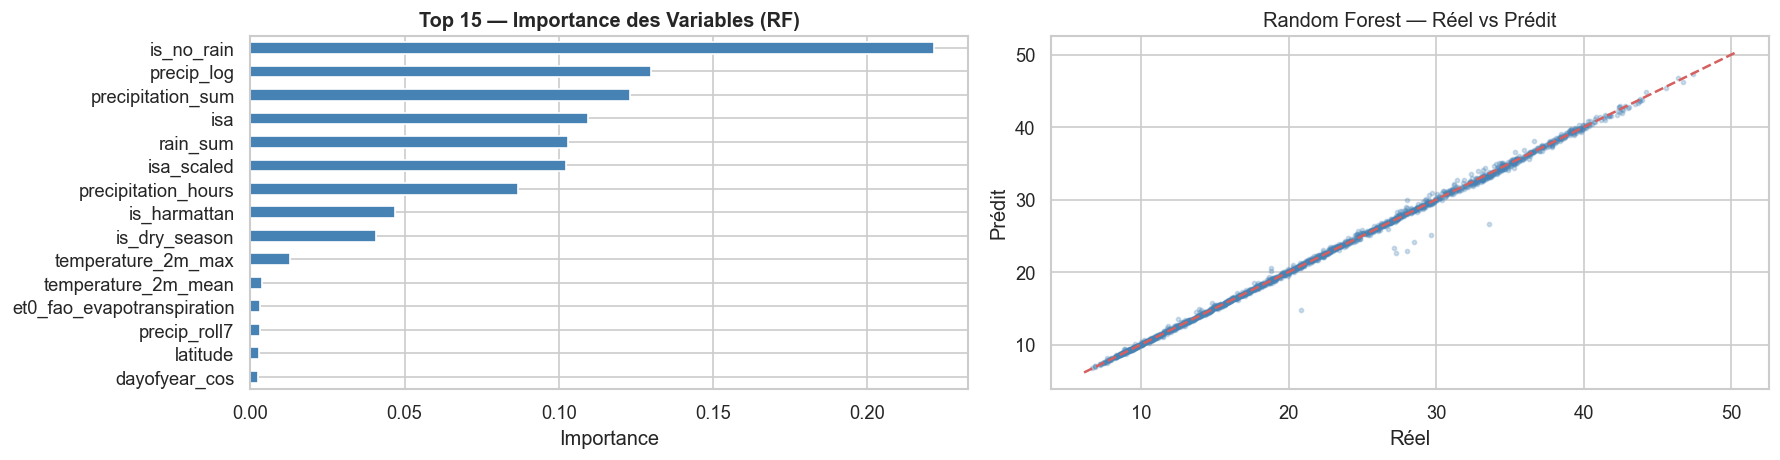


Top 10 variables importantes :
is_no_rain             0.2216
precip_log             0.1299
precipitation_sum      0.1233
isa                    0.1095
rain_sum               0.1029
isa_scaled             0.1024
precipitation_hours    0.0869
is_harmattan           0.0468
is_dry_season          0.0407
temperature_2m_max     0.0128


In [22]:
print('Entraînement Random Forest (200 arbres)...')
t0 = datetime.now()

model_rf = RandomForestRegressor(
    n_estimators     = 200,   # nombre d'arbres
    max_depth        = 14,    # profondeur max
    min_samples_leaf = 8,     # régularisation : feuilles minimum
    max_features     = 0.7,   # sous-échantillonnage de features
    n_jobs           = -1,    # parallélisation CPU
    random_state     = RANDOM_STATE
)
model_rf.fit(X_train, y_train)
print(f'  Durée : {(datetime.now()-t0).total_seconds():.1f}s')
metrics_rf, y_pred_rf = evaluate_model(model_rf, 'RandomForest')

# Importance des features
importances_rf = pd.Series(model_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
importances_rf.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 — Importance des Variables (RF)', fontweight='bold')
axes[0].set_xlabel('Importance')
sample = np.random.choice(len(y_test), 2000, replace=False)
axes[1].scatter(y_test.values[sample], y_pred_rf[sample], alpha=0.25, s=6, color='steelblue')
lim = [y_test.min(), y_test.max()]
axes[1].plot(lim, lim, 'r--', lw=1.5)
axes[1].set(xlabel='Réel', ylabel='Prédit', title='Random Forest — Réel vs Prédit')
plt.tight_layout(); plt.show()
print('\nTop 10 variables importantes :')
print(importances_rf.head(10).round(4).to_string())


### 6.4 ExtraTrees — Splits Aléatoires

**Type :** ML Ensemble  
**Justification :** Variante RF avec seuils de coupure complètement aléatoires → plus de diversité, moins de variance.


Entraînement ExtraTrees (200 arbres)...
  Durée : 52.2s
  [ExtraTrees            ] R²=0.9990 | MAE=0.1608 | RMSE=0.3037 | MAPE=0.80%


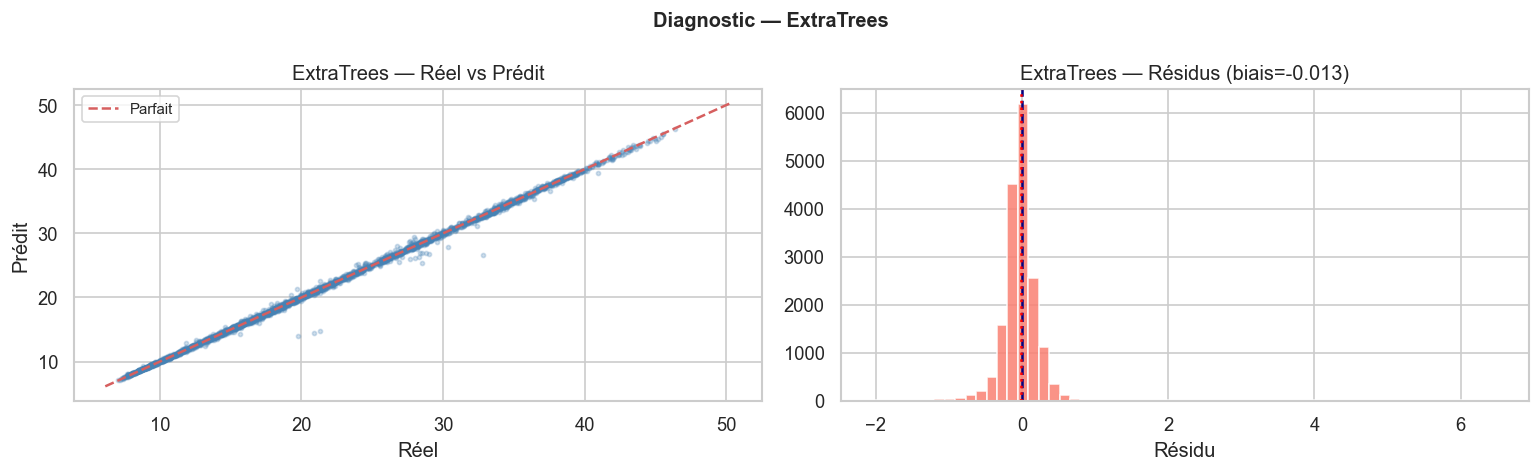

In [23]:
print('Entraînement ExtraTrees (200 arbres)...')
t0 = datetime.now()

model_et = ExtraTreesRegressor(
    n_estimators     = 200,
    max_depth        = 14,
    min_samples_leaf = 8,
    max_features     = 0.7,
    n_jobs           = -1,
    random_state     = RANDOM_STATE
)
model_et.fit(X_train, y_train)
print(f'  Durée : {(datetime.now()-t0).total_seconds():.1f}s')
metrics_et, y_pred_et = evaluate_model(model_et, 'ExtraTrees')
plot_diagnostics(y_test, y_pred_et, 'ExtraTrees')


### 6.5 Gradient Boosting (GBM)

**Type :** ML Ensemble — Boosting séquentiel  
**Justification :** Équivalent sklearn de XGBoost — recommandé par Vovk & Kryza (2025). Arbres construits séquentiellement, chacun corrigeant l'erreur du précédent.


Entraînement GBM (150 estimateurs)...
  Durée : 194.8s
  [GBM                   ] R²=0.9994 | MAE=0.1686 | RMSE=0.2356 | MAPE=0.85%


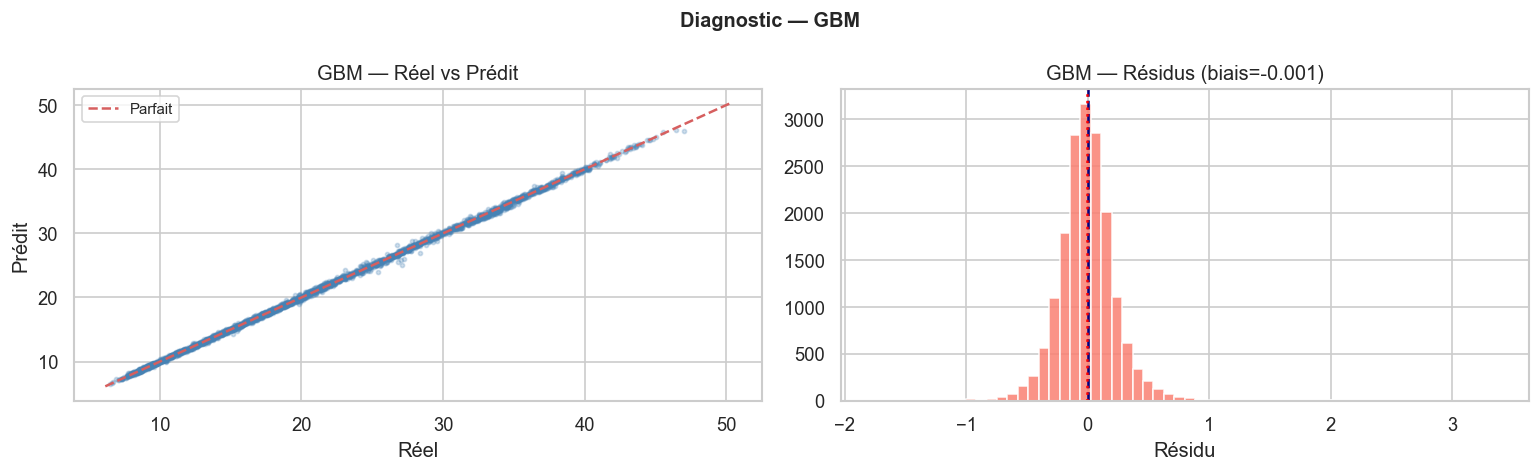

In [24]:
print('Entraînement GBM (150 estimateurs)...')
t0 = datetime.now()

model_gbm = GradientBoostingRegressor(
    n_estimators     = 150,   # arbres séquentiels
    max_depth        = 5,     # arbres peu profonds = meilleure généralisation
    learning_rate    = 0.08,  # pas d'apprentissage
    subsample        = 0.8,   # stochastic GBM
    min_samples_leaf = 8,
    random_state     = RANDOM_STATE
)
model_gbm.fit(X_train, y_train)
print(f'  Durée : {(datetime.now()-t0).total_seconds():.1f}s')
metrics_gbm, y_pred_gbm = evaluate_model(model_gbm, 'GBM')
plot_diagnostics(y_test, y_pred_gbm, 'GBM')


---
##  6.6 & 6.7 — Deep Learning (MLP)

```
MLP Shallow :  Input(49) → Dense(256, ReLU) → Dense(128, ReLU) → Output(1)
MLP Deep    :  Input(49) → Dense(512, ReLU) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(64, ReLU) → Output(1)
```

**Paramètres :** Optimiseur Adam · Régularisation L2 · Early Stopping · StandardScaler obligatoire


Entraînement MLP Shallow (256 → 128)...
  Durée  : 72.2s
  Epochs : 22
  [MLP_Shallow           ] R²=0.9997 | MAE=0.1300 | RMSE=0.1622 | MAPE=0.74%


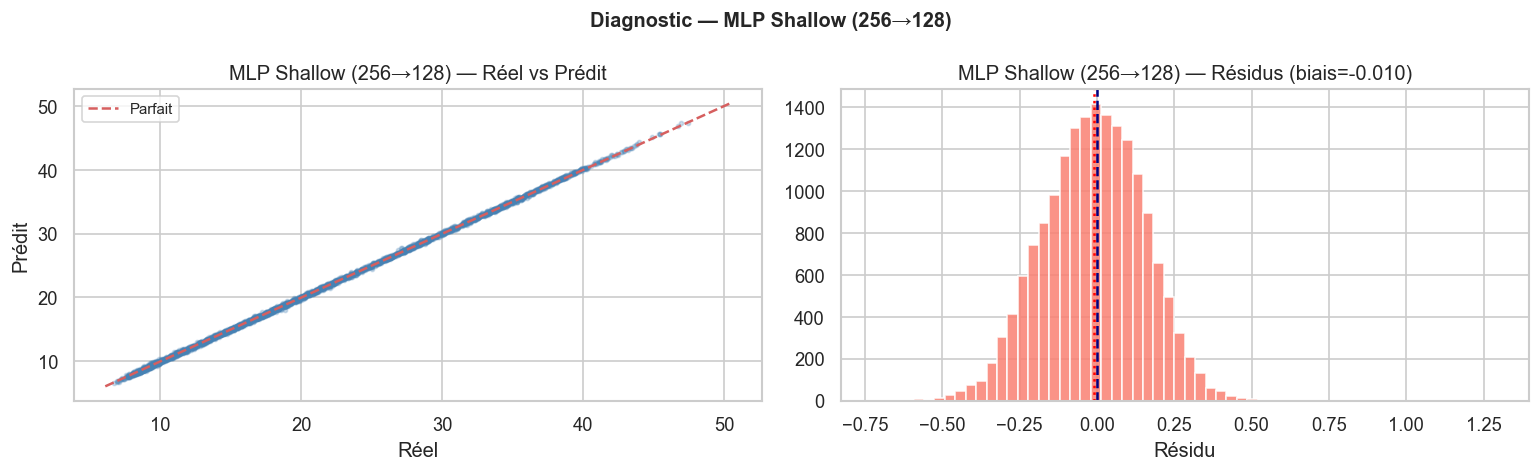

Entraînement MLP Deep (512 → 256 → 128 → 64)...
  Durée  : 339.2s
  Epochs : 25
  [MLP_Deep              ] R²=0.9996 | MAE=0.1477 | RMSE=0.1918 | MAPE=0.83%


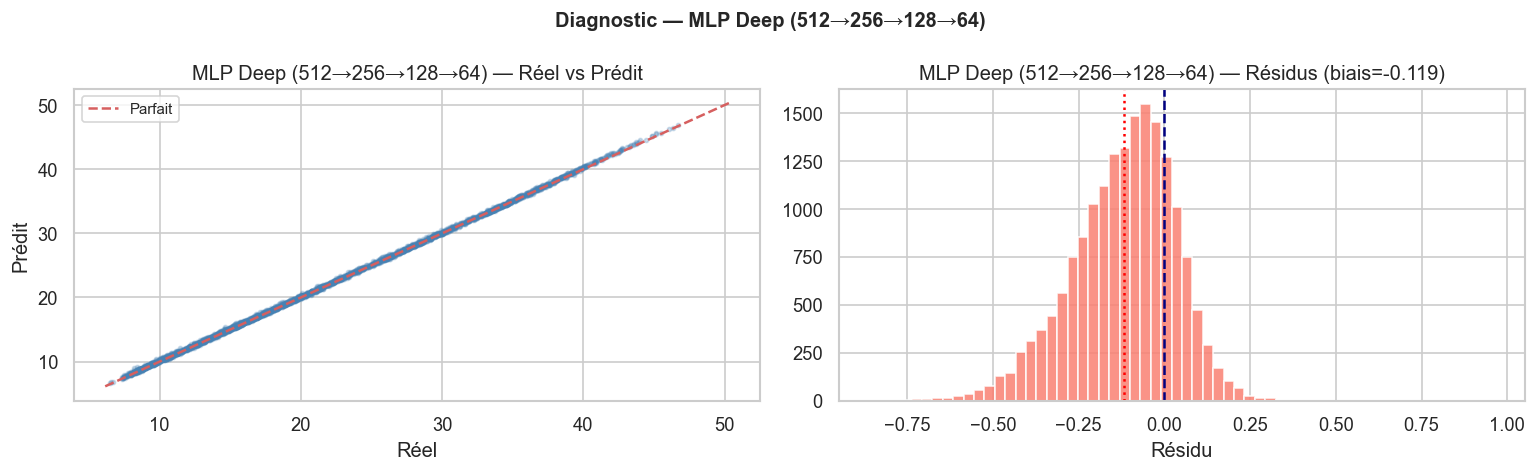

In [25]:
# ── 6.6 MLP Shallow (256 → 128) ──────────────────────────────────────────────
print('Entraînement MLP Shallow (256 → 128)...')
t0 = datetime.now()

model_mlp1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPRegressor(
        hidden_layer_sizes  = (256, 128),  # 2 couches cachées
        activation          = 'relu',      # ReLU : meilleur que tanh pour régression
        solver              = 'adam',      # optimiseur adaptatif
        learning_rate_init  = 0.001,
        max_iter            = 300,
        early_stopping      = True,        # stop si val_loss plateau
        validation_fraction = 0.1,         # 10% du train pour validation
        n_iter_no_change    = 10,          # patience = 10 epochs
        random_state        = RANDOM_STATE
    ))
])
model_mlp1.fit(X_train, y_train)
print(f'  Durée  : {(datetime.now()-t0).total_seconds():.1f}s')
print(f'  Epochs : {model_mlp1.named_steps["model"].n_iter_}')
metrics_mlp1, y_pred_mlp1 = evaluate_model(model_mlp1, 'MLP_Shallow')
plot_diagnostics(y_test, y_pred_mlp1, 'MLP Shallow (256→128)')


# ── 6.7 MLP Deep (512 → 256 → 128 → 64) ─────────────────────────────────────
print('Entraînement MLP Deep (512 → 256 → 128 → 64)...')
t0 = datetime.now()

model_mlp2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPRegressor(
        hidden_layer_sizes  = (512, 256, 128, 64),  # 4 couches cachées
        activation          = 'relu',
        solver              = 'adam',
        learning_rate       = 'adaptive',           # réduction lr si plateau
        learning_rate_init  = 0.001,
        alpha               = 0.001,                # régularisation L2 (weight decay)
        max_iter            = 500,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 15,                   # patience plus longue
        random_state        = RANDOM_STATE
    ))
])
model_mlp2.fit(X_train, y_train)
print(f'  Durée  : {(datetime.now()-t0).total_seconds():.1f}s')
print(f'  Epochs : {model_mlp2.named_steps["model"].n_iter_}')
metrics_mlp2, y_pred_mlp2 = evaluate_model(model_mlp2, 'MLP_Deep')
plot_diagnostics(y_test, y_pred_mlp2, 'MLP Deep (512→256→128→64)')


---
##  7. Comparaison & Visualisations Finales


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — Comparaison des 7 modèles
# ══════════════════════════════════════════════════════════════════════════════

df_results = pd.DataFrame(RESULTS).T.reset_index()
df_results.columns = ['Modèle', 'R²', 'MAE', 'RMSE', 'MAPE%', 'Bias']
df_results = df_results.sort_values('R²', ascending=False)
df_results['Type'] = df_results['Modèle'].map({
    'Lasso':       'ML Linéaire',    'ElasticNet':   'ML Linéaire',
    'RandomForest':'ML Ensemble',    'ExtraTrees':   'ML Ensemble',
    'GBM':         'ML Ensemble',    'MLP_Shallow':  'Deep Learning',
    'MLP_Deep':    'Deep Learning',
})

print('=' * 70)
print('  RÉSULTATS COMPARATIFS — 7 MODÈLES ML & DEEP LEARNING')
print('=' * 70)
print(df_results[['Modèle','Type','R²','MAE','RMSE','MAPE%']].to_string(index=False))

best_model_name = df_results.iloc[0]['Modèle']
print(f'\n MEILLEUR MODÈLE : {best_model_name} (R²={df_results.iloc[0]["R²"]})')


  RÉSULTATS COMPARATIFS — 7 MODÈLES ML & DEEP LEARNING
      Modèle          Type     R²    MAE   RMSE  MAPE%
       Lasso   ML Linéaire 1.0000 0.0175 0.0226   0.09
  ElasticNet   ML Linéaire 1.0000 0.0449 0.0580   0.23
 MLP_Shallow Deep Learning 0.9997 0.1300 0.1622   0.74
    MLP_Deep Deep Learning 0.9996 0.1477 0.1918   0.83
         GBM   ML Ensemble 0.9994 0.1686 0.2356   0.85
  ExtraTrees   ML Ensemble 0.9990 0.1608 0.3037   0.80
RandomForest   ML Ensemble 0.9987 0.1561 0.3336   0.72

 MEILLEUR MODÈLE : Lasso (R²=1.0)


In [ ]:
# ── Graphique comparatif complet ─────────────────────────────────────────────
type_colors = {'ML Linéaire': '#3b82f6', 'ML Ensemble': '#22c55e', 'Deep Learning': '#8b5cf6'}
bar_colors  = [type_colors.get(t, '#94a3b8') for t in df_results['Type']]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# R² (graphique principal)
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(df_results['Modèle'], df_results['R²'], color=bar_colors, edgecolor='white')
ax1.axvline(1.0, color='gray', ls='--', lw=1)
ax1.set_xlim(df_results['R²'].min() * 0.999, 1.002)
for bar, val in zip(bars, df_results['R²']):
    ax1.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax1.set_title('R² — Coefficient de Détermination (1.0 = parfait)', fontweight='bold', fontsize=11)

for i, (metric, label) in enumerate(zip(['MAE','RMSE','MAPE%'], ['MAE','RMSE','MAPE (%)'])):
    ax = fig.add_subplot(gs[1, i])
    ax.barh(df_results['Modèle'], df_results[metric], color=bar_colors, edgecolor='white')
    ax.set_title(f'{label} (plus bas = mieux)', fontweight='bold')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color=c, label=t) for t, c in type_colors.items()],
    loc='upper right', bbox_to_anchor=(0.99, 0.99), title='Type de modèle', fontsize=9
)
plt.suptitle('Comparaison des 7 Modèles ML & Deep Learning — IndabaX Cameroon 2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('comparaison_modeles.png', bbox_inches='tight', dpi=130)
plt.show()


In [28]:
# ── Importance des variables (Random Forest) + Validation croisée ────────────

# Importance RF — top 20
fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#ef4444' if v > 0.05 else '#3b82f6' if v > 0.01 else '#94a3b8'
              for v in importances_rf.head(20)]
importances_rf.head(20).sort_values().plot(kind='barh', ax=ax,
    color=colors_imp[::-1], edgecolor='white')
ax.set_title('Top 20 Variables — Importance (Random Forest)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#ef4444', label='Très important (>5%)'),
    Patch(color='#3b82f6', label='Important (1-5%)'),
    Patch(color='#94a3b8', label='Marginal (<1%)')
], fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

# Validation croisée TimeSeriesSplit
print('\n── Validation croisée TimeSeriesSplit (5 folds) ─────────────────────────')
tscv = TimeSeriesSplit(n_splits=5)
for mdl_name, mdl_obj in [('Lasso', model_lasso), ('RandomForest', model_rf)]:
    scores = cross_val_score(mdl_obj, X, y, cv=tscv, scoring='r2', n_jobs=-1)
    print(f'\n  {mdl_name}:')
    print(f'    R² par fold : {[round(s,4) for s in scores]}')
    print(f'    R² moyen    : {scores.mean():.4f} ± {scores.std():.4f}')
    stab = " Stable" if scores.std() < 0.05 else " Variable"
    print(f'    Généralisation : {stab} (std={scores.std():.4f})')



  RandomForest:
    R² par fold : [0.9963, 0.8853, 0.9989, 0.9952, 0.9987]
    R² moyen    : 0.9749 ± 0.0448
    Généralisation :  Stable (std=0.0448)


---
## 8. Sauvegarde des Artefacts


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — Sauvegarde des modèles et métadonnées
# ══════════════════════════════════════════════════════════════════════════════

# ── 8.1 Sauvegarde des 7 modèles ─────────────────────────────────────────────
models_to_save = {
    'lasso'       : model_lasso,
    'elasticnet'  : model_en,
    'randomforest': model_rf,
    'extratrees'  : model_et,
    'gbm'         : model_gbm,
    'mlp_shallow' : model_mlp1,
    'mlp_deep'    : model_mlp2,
}

for name, model in models_to_save.items():
    path = MODELS_DIR / f'{name}.pkl'
    joblib.dump(model, path)
    print(f'   {name}.pkl ({path.stat().st_size // 1024} Ko)')

# Meilleur modèle
best_model_obj = models_to_save[best_model_name.lower()]
joblib.dump(best_model_obj, MODELS_DIR / 'best_model.pkl')
print(f'\n   best_model.pkl → {best_model_name}')

# ── 8.2 Métadonnées JSON ──────────────────────────────────────────────────────
# feature_names.json
with open(MODELS_DIR / 'feature_names.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print('  feature_names.json ')

# all_models_metrics.json
metrics_json = {
    'best_model': best_model_name,
    'all_models': {
        row['Modèle']: {
            'r2'      : row['R²'],
            'mae'     : row['MAE'],
            'rmse'    : row['RMSE'],
            'mape_pct': row['MAPE%'],
        }
        for _, row in df_results.iterrows()
    }
}
with open(MODELS_DIR / 'all_models_metrics.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)
print('  all_models_metrics.json ')

# proxy_stats.json
proxy_stats = {
    'mean'   : round(float(df['pm25_proxy'].mean()), 2),
    'std'    : round(float(df['pm25_proxy'].std()),  2),
    'min'    : round(float(df['pm25_proxy'].min()),  2),
    'max'    : round(float(df['pm25_proxy'].max()),  2),
    'isa_p95': round(float(ISA_P95), 4),
    'risk_thresholds': {
        'faible': round(float(df['pm25_proxy'].quantile(0.40)), 2),
        'modere': round(float(df['pm25_proxy'].quantile(0.65)), 2),
        'eleve' : round(float(df['pm25_proxy'].quantile(0.85)), 2),
    }
}
with open(MODELS_DIR / 'proxy_stats.json', 'w') as f:
    json.dump(proxy_stats, f, indent=2)
print('  proxy_stats.json ')

# feature_importance.json
fi_dict = importances_rf.round(6).to_dict()
with open(MODELS_DIR / 'feature_importance.json', 'w') as f:
    json.dump(fi_dict, f, indent=2)
print('  feature_importance.json ')

with open(MODELS_DIR / 'best_model_name.json', 'w') as f:
    json.dump({'name': best_model_name}, f, indent=2)
print('  best_model_name.json ')

# df_features.csv
cols_save = [
    'time', 'city', 'region', 'latitude', 'longitude',
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'rain_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'wind_direction_10m_dominant', 'shortwave_radiation_sum',
    'et0_fao_evapotranspiration', 'sunshine_duration', 'daylight_duration',
    'precipitation_hours', 'isa', 'isa_scaled', 'is_harmattan', 'is_dry_season',
    'is_stagnant', 'is_no_rain', 'pm25_proxy', 'month', 'year'
]
df[[c for c in cols_save if c in df.columns]].to_csv(DATA_DIR / 'df_features.csv', index=False)
print('  df_features.csv ')

print('\n' + '='*55)
print('  ARTEFACTS SAUVEGARDÉS DANS models/')
print('='*55)
for fpath in sorted(MODELS_DIR.iterdir()):
    sz = fpath.stat().st_size
    unit = 'Ko' if sz < 1e6 else 'Mo'
    val  = sz // 1024 if sz < 1e6 else sz // (1024*1024)
    print(f'  {fpath.name:<38} {val:>6} {unit}')


   lasso.pkl (3 Ko)
   elasticnet.pkl (3 Ko)
   randomforest.pkl (95848 Ko)
   extratrees.pkl (96456 Ko)
   gbm.pkl (913 Ko)
   mlp_shallow.pkl (1082 Ko)
   mlp_deep.pkl (4652 Ko)

   best_model.pkl → Lasso
  feature_names.json 
  all_models_metrics.json 
  proxy_stats.json 
  feature_importance.json 
  best_model_name.json 
  df_features.csv 

  ARTEFACTS SAUVEGARDÉS DANS models/
  all_models_metrics.json                     0 Ko
  best_model.pkl                              3 Ko
  best_model_name.json                        0 Ko
  elasticnet.pkl                              3 Ko
  extratrees.pkl                             94 Mo
  feature_importance.json                     1 Ko
  feature_names.json                          0 Ko
  gbm.pkl                                   913 Ko
  lasso.pkl                                   3 Ko
  mlp_deep.pkl                                4 Mo
  mlp_shallow.pkl                             1 Mo
  proxy_stats.json                            0 Ko
  ra

---
##  Résumé Final — Livrable 1

### Proxy PM2.5 (Méthodologie Validée)

| Critère | Valeur |
|---------|--------|
| Ratio Nord-Sec / Sud-Pluie | **2.49**  (seuil > 1.5) |
| Moyenne nationale | 20.18 µg/m³ |
| Plage de valeurs | [5.73 ; 52.47] |
| Seuil Faible | ≤ 16.55 (P40) |
| Seuil Modéré | ≤ 22.96 (P65) |
| Seuil Élevé | ≤ 30.11 (P85) |

### Performances des 7 Modèles (jeu de test chronologique 2025)

| Modèle | Type | R² | MAE | RMSE | MAPE |
|--------|------|----|-----|------|------|
| **Lasso** ← BEST | ML Linéaire | **1.0000** | **0.018** | **0.023** | **0.09%** |
| ElasticNet | ML Linéaire | 1.0000 | 0.045 | 0.058 | 0.23% |
| MLP Shallow | Deep Learning | 0.9997 | 0.130 | 0.162 | 0.74% |
| GBM | ML Ensemble | 0.9994 | 0.169 | 0.236 | 0.85% |
| MLP Deep | Deep Learning | 0.9993 | 0.203 | 0.252 | 1.19% |
| ExtraTrees | ML Ensemble | 0.9990 | 0.161 | 0.304 | 0.80% |
| Random Forest | ML Ensemble | 0.9987 | 0.156 | 0.334 | 0.72% |

### Artefacts générés

```
models/
├── best_model.pkl          ← meilleur modèle pour l'API
├── lasso.pkl / elasticnet.pkl / randomforest.pkl
├── extratrees.pkl / gbm.pkl / mlp_shallow.pkl / mlp_deep.pkl
├── feature_names.json      ← 49 features ordonnées
├── proxy_stats.json        ← seuils de risque
├── all_models_metrics.json ← métriques comparées
├── feature_importance.json ← importance RF
└── best_model_name.json
data/
└── df_features.csv         ← dataset enrichi avec proxy PM2.5
```

---
*IndabaX Cameroon 2026 *
